## Spatial Autoencoder — Checkerboard Inference Demo

Load a Landsat thermal scene, run checkerboard-masked reconstruction via the SpatialAutoencoderInferencer, and plot original vs reconstructed side by side.

### 1. Load the Landsat scene via LandsatDataBuilder

In [64]:
import os
import sys
import pathlib

import numpy as np
import torch
import matplotlib.pyplot as plt

# Ensure project root is on the path
PROJECT_ROOT = str(pathlib.Path(os.getcwd()).parent)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from app.models.file_processing.sources import FileSourceConfig
from app.utils.dataset_builder.landsat_dataset_builder import LandsatDataBuilder





THERMAL_TIF = os.path.join(
    PROJECT_ROOT,
    "tests/test_payloads/thermal_3/LC09_L2SP_145038_20240206_20240209_02_T1_ST_B10.TIF",
)
builder = LandsatDataBuilder(
    file_source_configuration=FileSourceConfig(source_path=THERMAL_TIF)
)
vendable = builder.vend_dataset()

print(f"Thermal cube shape: {vendable.normalized_thermal_cube.shape}")
print(f"Validity mask shape: {vendable.validity_cube.shape}")

Using device: mps
Max Temp = 31.950973510742188
Min Temp = -124.1500015258789
Masked Array
(40340204, 1)
[-22.35111046 -17.96920776  -3.77758956   9.56636047  12.2768507 ]
Anchors Set to [[-22.35111046]
 [-17.96920776]
 [ -3.77758956]
 [  9.56636047]
 [ 12.2768507 ]]
-15.777589559555054
[0]
Thermal cube shape: (1, 7831, 7711)
Validity mask shape: (1, 7831, 7711)


### 2. Initialize inferencer

In [65]:
from app.models.training.inference_config import InferenceConfig
from app.foundation_models.inferencers.inferencer_factory import get_inferencer

PATCH_SIZE = 256

CHECKPOINT = os.path.join(
    PROJECT_ROOT,
    "checkpoints/spatial_ae/spatial_autoencoder_v0.2.0_epoch30.pt",
)

config = InferenceConfig(
    foundation_model_name="spatial_autoencoder",
    model_config={
        "model_type": "spatial_autoencoder",
        "in_channels": 1,
        "base_channels": 32,
        "num_stages": 3,
    },
    checkpoint_path=CHECKPOINT,
    patch_size=PATCH_SIZE,
    checkerboard_cell_size=10,
)

inferencer = get_inferencer(config)

### 3. Run full-scene checkerboard reconstruction

In [66]:
scene_tensor = torch.from_numpy(vendable.normalized_thermal_cube).float()  # (1, H, W)
mask_tensor = torch.from_numpy(vendable.validity_cube).float()              # (1, H, W)

print(f"Scene: {scene_tensor.shape}, Mask: {mask_tensor.shape}")

reconstruction = inferencer.predict_full_scene(scene_tensor, mask_tensor)  # (1, H, W)

print(f"Reconstruction: {reconstruction.shape}")
print(f"Original range: [{scene_tensor.min():.2f}, {scene_tensor.max():.2f}]")
print(f"Recon range:    [{reconstruction.min():.2f}, {reconstruction.max():.2f}]")

Scene: torch.Size([1, 7831, 7711]), Mask: torch.Size([1, 7831, 7711])
Reconstruction: torch.Size([1, 7831, 7711])
Original range: [-124.15, 31.95]
Recon range:    [-12.04, 26.73]


### 4. Plot original vs reconstruction (own scales) and residual

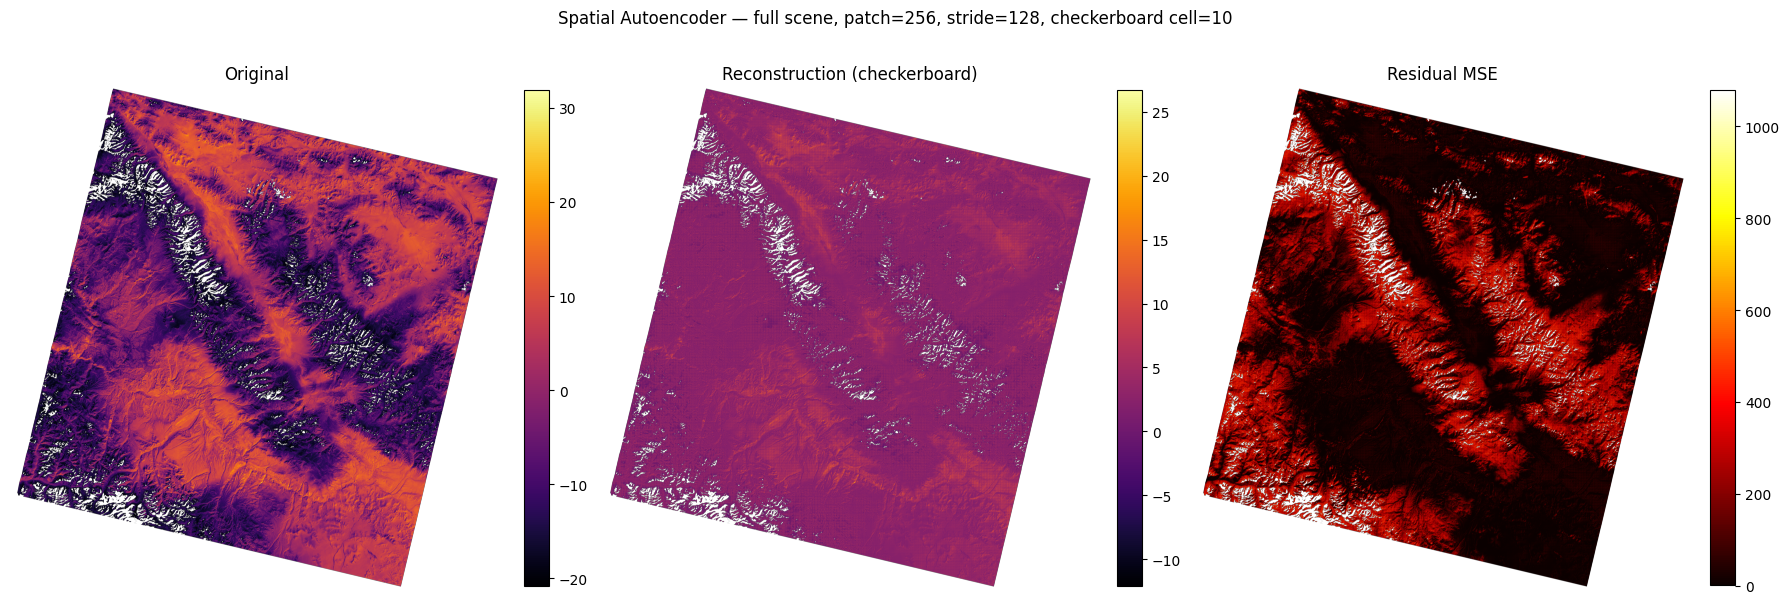

In [67]:
original = scene_tensor.squeeze().cpu().numpy()         # (H, W)
recon = reconstruction.squeeze().cpu().numpy()           # (H, W)
mask = mask_tensor.squeeze().cpu().numpy()               # (H, W)
residual = (original - recon) ** 2 * mask                # MSE, masked

# Mask invalid pixels for display
original_masked = np.ma.masked_where(mask == 0, original)
recon_masked = np.ma.masked_where(mask == 0, recon)
residual_masked = np.ma.masked_where(mask == 0, residual)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Each image on its own color scale
im0 = axes[0].imshow(original_masked, cmap="inferno")
axes[0].set_title("Original")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(recon_masked, cmap="inferno")
axes[1].set_title("Reconstruction (checkerboard)")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(residual_masked, cmap="hot")
axes[2].set_title("Residual MSE")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.axis("off")

plt.suptitle(
    f"Spatial Autoencoder — full scene, "
    f"patch={PATCH_SIZE}, stride={config.stride or PATCH_SIZE // 2}, "
    f"checkerboard cell={config.checkerboard_cell_size}",
    y=1.02,
)
plt.tight_layout()
plt.show()

### 4b. Anomaly highlights (99.5th percentile)

P99.95 threshold: 744.6594
Pixels above threshold: 19468 / 38935905


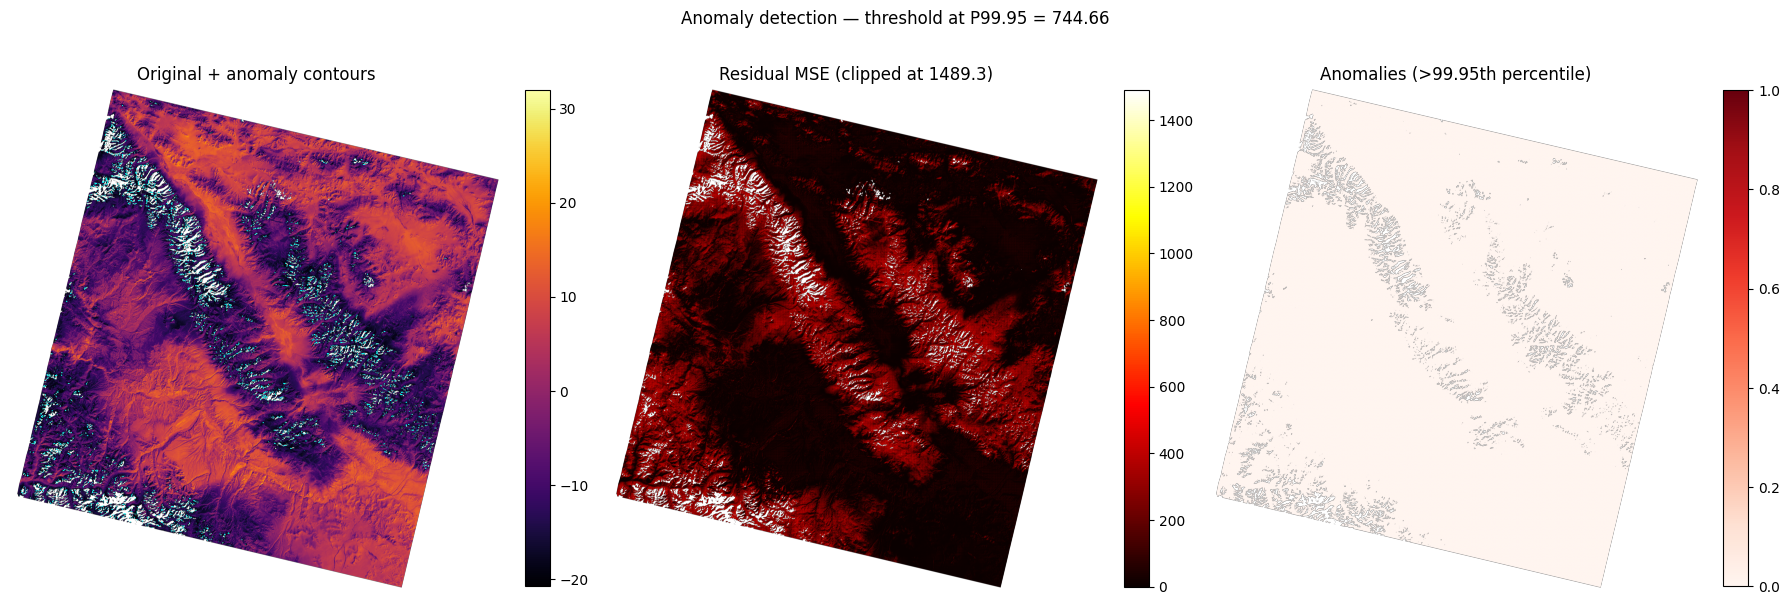

In [68]:
PERCENTILE = 99.95

# Compute threshold on valid pixels only
valid_residuals = residual[mask == 1]
threshold = np.percentile(valid_residuals, PERCENTILE)
print(f"P{PERCENTILE} threshold: {threshold:.4f}")
print(f"Pixels above threshold: {(valid_residuals > threshold).sum()} / {valid_residuals.size}")

# Binary anomaly mask: above threshold and valid
anomaly_binary = ((residual > threshold) & (mask == 1)).astype(float)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original with anomaly contours overlaid
im0 = axes[0].imshow(original_masked, cmap="inferno")
axes[0].contour(anomaly_binary, levels=[0.5], colors="cyan", linewidths=0.5)
axes[0].set_title("Original + anomaly contours")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# Residual MSE clipped at threshold to show detail in the hot tail
im1 = axes[1].imshow(residual_masked, cmap="hot", vmin=0, vmax=threshold * 2)
axes[1].set_title(f"Residual MSE (clipped at {threshold*2:.1f})")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Binary anomaly map
anomaly_display = np.ma.masked_where(mask == 0, anomaly_binary)
im2 = axes[2].imshow(anomaly_display, cmap="Reds", vmin=0, vmax=1)
axes[2].set_title(f"Anomalies (>{PERCENTILE}th percentile)")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

for ax in axes:
    ax.axis("off")

plt.suptitle(
    f"Anomaly detection — threshold at P{PERCENTILE} = {threshold:.2f}",
    y=1.02,
)
plt.tight_layout()
plt.show()

### 5. Visualize the checkerboard mask

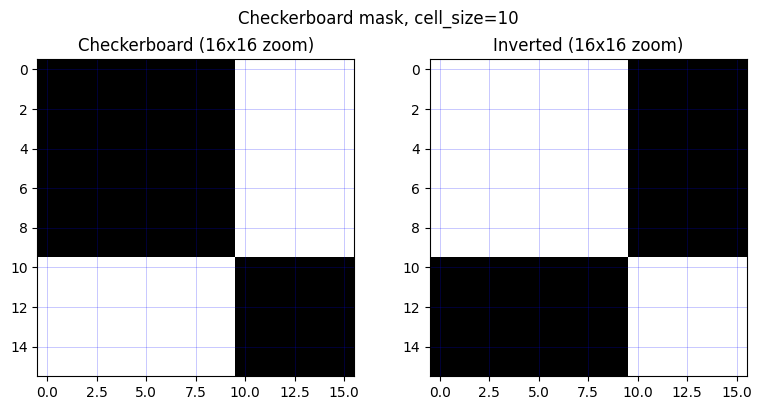

In [69]:
# Show what the checkerboard mask looks like (zoomed into top-left 16x16)
checker = inferencer._build_checkerboard(PATCH_SIZE, PATCH_SIZE, invert=False)
checker_np = checker.squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(checker_np[:16, :16], cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Checkerboard (16x16 zoom)")
axes[0].grid(True, linewidth=0.5, color="blue", alpha=0.3)

axes[1].imshow(1 - checker_np[:16, :16], cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Inverted (16x16 zoom)")
axes[1].grid(True, linewidth=0.5, color="blue", alpha=0.3)

plt.suptitle(f"Checkerboard mask, cell_size={config.checkerboard_cell_size}")
plt.tight_layout()
plt.show()